In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import pickle
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric_temporal.signal import StaticGraphTemporalSignal, temporal_signal_split
from torch_geometric.nn import TransformerConv, GATConv
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: LOAD ORIGINAL DATA (BEFORE SCALING)
# ============================================================================

# Load NodesIndex.csv, keep unique by NodeIndex, and sort
node_idx_df = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\NodesIndex.csv')
node_idx_df = node_idx_df.drop_duplicates(subset='NodeIndex', keep='first').sort_values('NodeIndex')
nodes_list = node_idx_df['Node'].tolist()
print(f"Number of unique nodes: {len(nodes_list)}")

# Create mapping
node_to_idx = dict(zip(nodes_list, range(40)))

# Load edges
edges_df = pd.read_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\Edges (Storage Location).csv')

edge_index = []
edge_weight = []
for _, row in edges_df.iterrows():
    u = node_to_idx.get(row['node1'])
    v = node_to_idx.get(row['node2'])
    if u is not None and v is not None:
        edge_index.append([u, v])
        edge_weight.append(row['Storage Location'])

edge_index = np.array(edge_index).T
edge_weight = np.array(edge_weight).reshape(-1, 1)

def load_and_filter(file_path):
    df = pd.read_csv(file_path)
    df = df.drop('Date', axis=1)
    df = df[[col for col in df.columns if col in nodes_list]]
    df = df[nodes_list]
    return df.values

sales       = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Sales Order.csv')
production  = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Production .csv')
factory     = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Factory Issue.csv')
delivery    = load_and_filter(r'C:\Users\KIIT0001\ai_engine\trade_data\Delivery To distributor.csv')

print("Sales shape:", sales.shape)           # (221, 40)
print("Production shape:", production.shape)
print("Factory shape:", factory.shape)
print("Delivery shape:", delivery.shape)

# Stack features
features = np.stack([production, factory, delivery, sales], axis=2)
targets = sales   # ORIGINAL UNSCALED TARGETS

print("Features shape:", features.shape)   # (221, 40, 4)
print("Targets shape:", targets.shape)     # (221, 40)

# ============================================================================
# 🔥 ADD THIS HERE - CREATE AND SAVE TARGET SCALER
# ============================================================================

print("\n" + "="*70)
print("CREATING TARGET SCALER FROM ORIGINAL DATA")
print("="*70)

# Shift for next-day prediction (like you did before)
features_shifted = features[:-1]   # (220, 40, 4)
targets_shifted = targets[1:]      # (220, 40) - next day sales

# Calculate train size (80%)
train_size = int(0.8 * len(targets_shifted))  # 176 snapshots
print(f"Train size: {train_size} snapshots")
print(f"Test size: {len(targets_shifted) - train_size} snapshots")

# Get TRAINING targets only (before scaling)
train_targets_original = targets_shifted[:train_size]  # (176, 40)
print(f"Train targets shape: {train_targets_original.shape}")

# Flatten training targets for scaler
train_targets_flat = train_targets_original.reshape(-1, 1)  # (7040, 1) = 176*40
print(f"Train targets flattened: {train_targets_flat.shape}")

# Create and fit scaler on TRAINING data only
target_scaler = StandardScaler()
target_scaler.fit(train_targets_flat)

print(f"\nTarget Scaler Parameters:")
print(f"  Mean: {target_scaler.mean_[0]:.2f}")
print(f"  Std:  {target_scaler.scale_[0]:.2f}")

# Save the scaler
scaler_path = r'C:\Users\KIIT0001\ai_engine\trade_data\target_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(target_scaler, f)
print(f"\n✓ Target scaler saved to: {scaler_path}")

print("="*70)

# ============================================================================
# CONTINUE WITH YOUR EXISTING SCALING CODE
# ============================================================================

# Scale features (input)
X_flat = features_shifted.reshape(-1, 4)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_flat)
features_scaled = X_scaled.reshape(features_shifted.shape)

# Scale targets (output)
y_flat = targets_shifted.reshape(-1, 1)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_flat).flatten()
targets_scaled = y_scaled.reshape(targets_shifted.shape)

print(f"\n✓ Features and targets scaled")

# Create dataset with SCALED data
dataset = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=features_scaled,
    targets=targets_scaled
)

# Split dataset
train_dataset, test_dataset = temporal_signal_split(dataset, train_ratio=0.8)

print(f"Train snapshots: {len(list(train_dataset))}")
print(f"Test snapshots: {len(list(test_dataset))}")

# Continue with your training...

Number of unique nodes: 40
Sales shape: (221, 40)
Production shape: (221, 40)
Factory shape: (221, 40)
Delivery shape: (221, 40)
Features shape: (221, 40, 4)
Targets shape: (221, 40)

CREATING TARGET SCALER FROM ORIGINAL DATA
Train size: 176 snapshots
Test size: 44 snapshots
Train targets shape: (176, 40)
Train targets flattened: (7040, 1)

Target Scaler Parameters:
  Mean: 912.85
  Std:  2590.29

✓ Target scaler saved to: C:\Users\KIIT0001\ai_engine\trade_data\target_scaler.pkl

✓ Features and targets scaled
Train snapshots: 176
Test snapshots: 44


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv, GATv2Conv, global_mean_pool
import math

# ============================================================================
# 3. HYBRID MODEL (GRAPH TRANSFORMER + GAT)
# ============================================================================

class HybridGraphModel(nn.Module):
    """
    Combines global attention (Transformer) with local attention (GAT)
    This captures both local supply chain relationships and global patterns
    """
    def __init__(
        self,
        in_channels: int = 4,
        hidden_channels: int = 64,
        num_layers: int = 2,
        dropout: float = 0.5
    ):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        
        # Local path (GAT for immediate neighbors)
        self.local_convs = nn.ModuleList()
        for _ in range(num_layers):
            self.local_convs.append(
                GATv2Conv(
                    hidden_channels,
                    hidden_channels // 4,
                    heads=4,
                    dropout=dropout,
                    edge_dim=1
                )
            )
        
        # Global path (Transformer for all nodes)
        self.global_convs = nn.ModuleList()
        for _ in range(num_layers):
            self.global_convs.append(
                TransformerConv(
                    hidden_channels,
                    hidden_channels // 4,
                    heads=4,
                    dropout=dropout,
                    edge_dim=1
                )
            )
        
        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.LayerNorm(hidden_channels),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        
        # Output
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)
        )
    
    def forward(self, x, edge_index, edge_attr=None):
        x = self.input_proj(x)
        
        # Local path
        x_local = x
        for conv in self.local_convs:
            x_local = conv(x_local, edge_index, edge_attr)
            x_local = F.gelu(x_local)
        
        # Global path
        x_global = x
        for conv in self.global_convs:
            x_global = conv(x_global, edge_index, edge_attr)
            x_global = F.gelu(x_global)
        
        # Fuse
        x_combined = torch.cat([x_local, x_global], dim=-1)
        x = self.fusion(x_combined)
        
        # Output
        return self.output_proj(x).squeeze(-1)

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Collect all training features into one array
train_features_list = []
for snap in train_dataset:
    train_features_list.append(snap.x)  # each snap.x is (40,4)
# Stack: (num_train_snapshots, 40, 4)
train_features = np.stack(train_features_list, axis=0)
print(f"Training features shape: {train_features.shape}")  # e.g., (176, 40, 4)

# Fit scaler on flattened features (all nodes, all time steps)
train_flat = train_features.reshape(-1, train_features.shape[-1])  # (176*40, 4)
scaler = StandardScaler()
scaler.fit(train_flat)
print("Scaler fitted on training data (mean, std per feature).")

Training features shape: (176, 40, 4)
Scaler fitted on training data (mean, std per feature).


In [6]:
def scale_features(features_array, scaler):
    # features_array shape: (T, N, F)
    flat = features_array.reshape(-1, features_array.shape[-1])
    scaled_flat = scaler.transform(flat)
    return scaled_flat.reshape(features_array.shape)

# Scale training features
train_features_scaled = scale_features(train_features, scaler)
print(f"Scaled training features shape: {train_features_scaled.shape}")

# Collect test features similarly
test_features_list = [snap.x for snap in test_dataset]
test_features = np.stack(test_features_list, axis=0)
test_features_scaled = scale_features(test_features, scaler)
print(f"Scaled test features shape: {test_features_scaled.shape}")

# Collect targets (they don't need scaling for MSE loss, but we keep them as is)
train_targets = np.stack([snap.y for snap in train_dataset], axis=0)  # (176, 40)
test_targets = np.stack([snap.y for snap in test_dataset], axis=0)    # (44, 40)
print(f"Train targets shape: {train_targets.shape}")
print(f"Test targets shape: {test_targets.shape}")

Scaled training features shape: (176, 40, 4)
Scaled test features shape: (44, 40, 4)
Train targets shape: (176, 40)
Test targets shape: (44, 40)


In [7]:
# Get edge info from any snapshot (they are constant)
first_snap = next(iter(train_dataset))
edge_index = first_snap.edge_index.numpy() if torch.is_tensor(first_snap.edge_index) else first_snap.edge_index
edge_weight = first_snap.edge_attr.numpy() if torch.is_tensor(first_snap.edge_attr) else first_snap.edge_attr

# Recreate datasets using StaticGraphTemporalSignal
from torch_geometric_temporal.signal import StaticGraphTemporalSignal

train_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=train_features_scaled,
    targets=train_targets
)

test_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=test_features_scaled,
    targets=test_targets
)

print("Datasets rebuilt with scaled features.")

Datasets rebuilt with scaled features.


In [8]:
# Convert train and test datasets to lists of snapshots
train_snapshots = list(train_dataset_scaled)
test_snapshots = list(test_dataset_scaled)

print(f"Number of train snapshots: {len(train_snapshots)}")   # Should be 176
print(f"Number of test snapshots: {len(test_snapshots)}")     # Should be 45

Number of train snapshots: 176
Number of test snapshots: 44


In [9]:
# Look at the first training snapshot
first = train_snapshots[0]
print("First snapshot:")
print(f"  x (features) shape: {first.x.shape}")          # (40, 4)
print(f"  edge_index shape: {first.edge_index.shape}")   # (2, 3046)
print(f"  edge_attr shape: {first.edge_attr.shape}")     # (3046, 1)
print(f"  y (target) shape: {first.y.shape}")            # (40,)
print("\nFirst 5 rows of x (scaled features):")
print(first.x[:5])
print("\nFirst 5 target values (scaled sales for next day):")
print(first.y[:5])

First snapshot:
  x (features) shape: torch.Size([40, 4])
  edge_index shape: torch.Size([2, 3046])
  edge_attr shape: torch.Size([3046, 1])
  y (target) shape: torch.Size([40])

First 5 rows of x (scaled features):
tensor([[ 0.0419, -0.2986, -0.2096,  0.1666],
        [ 0.8908,  0.7452,  0.6290,  4.4710],
        [-0.3859, -0.2692, -0.2627,  0.3941],
        [ 0.4774,  0.5178,  0.3740,  5.2224],
        [ 1.3186,  0.8110,  1.3685,  7.8413]])

First 5 target values (scaled sales for next day):
tensor([-0.2135,  4.4392,  0.4036,  5.0169,  6.6475])


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# from improved_supply_chain_models import ImprovedGraphTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Instantiate the model
model = ImprovedGraphTransformer(
    in_channels=4,
    hidden_channels=64,
    num_layers=2,
    num_heads=4,
    dropout=0.5
).to(device)

print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters.")

# Optimizer, scheduler, loss function
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
loss_fn = nn.MSELoss()

Using device: cpu


NameError: name 'ImprovedGraphTransformer' is not defined

In [11]:
from sklearn.preprocessing import StandardScaler

# Train targets: shape (176, 40)
train_targets_flat = train_targets.reshape(-1, 1)   # (176*40, 1)
target_scaler = StandardScaler()
target_scaler.fit(train_targets_flat)

def scale_targets(targets_array):
    flat = targets_array.reshape(-1, 1)
    scaled_flat = target_scaler.transform(flat)
    return scaled_flat.reshape(targets_array.shape)

train_targets_scaled = scale_targets(train_targets)
test_targets_scaled = scale_targets(test_targets)

print(f"Scaled train targets shape: {train_targets_scaled.shape}")   # (176, 40)
print(f"Scaled test targets shape: {test_targets_scaled.shape}")     # (45, 40)
print(f"Mean of scaled train targets: {train_targets_scaled.mean():.4f} (should be ~0)")
print(f"Std of scaled train targets: {train_targets_scaled.std():.4f} (should be ~1)")

Scaled train targets shape: (176, 40)
Scaled test targets shape: (44, 40)
Mean of scaled train targets: 0.0000 (should be ~0)
Std of scaled train targets: 1.0000 (should be ~1)


In [12]:
# Rebuild datasets with scaled features (already done) and scaled targets
train_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=train_features_scaled,
    targets=train_targets_scaled
)

test_dataset_scaled = StaticGraphTemporalSignal(
    edge_index=edge_index,
    edge_weight=edge_weight,
    features=test_features_scaled,
    targets=test_targets_scaled
)

# Convert to lists again
train_snapshots = list(train_dataset_scaled)
test_snapshots = list(test_dataset_scaled)

print(f"Train snapshots: {len(train_snapshots)}")
print(f"Test snapshots: {len(test_snapshots)}")

Train snapshots: 176
Test snapshots: 44


In [ ]:
import torch
import torch.nn as nn
# from improved_supply_chain_models import HybridGraphModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = HybridGraphModel(
    in_channels=4,
    hidden_channels=64,
    num_layers=2,
    dropout=0.5
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
loss_fn = nn.MSELoss()

best_test_loss = float('inf')
patience_counter = 0
early_stop_patience = 20

for epoch in range(1, 201):
    # Training
    model.train()
    train_loss = 0.0
    for snap in train_snapshots:  # ← Just iterate normally
        x = torch.tensor(snap.x, dtype=torch.float).to(device)  # ← Single snapshot
        edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
        edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
        y = torch.tensor(snap.y, dtype=torch.float).to(device)
        
        optimizer.zero_grad()
        out = model(x, edge_index, edge_attr)  # ← Pass single x (not sequence)
        loss = loss_fn(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_snapshots)
    
    # Evaluation
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for snap in test_snapshots:
            x = torch.tensor(snap.x, dtype=torch.float).to(device)
            edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
            edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
            y = torch.tensor(snap.y, dtype=torch.float).to(device)
            out = model(x, edge_index, edge_attr)
            test_loss += loss_fn(out, y).item()
    test_loss /= len(test_snapshots)
    
    scheduler.step(test_loss)
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), 'best_hybrid_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"Best test loss: {best_test_loss:.4f}")

Epoch 020 | Train Loss: 0.7414 | Test Loss: 0.2790
Epoch 040 | Train Loss: 0.6647 | Test Loss: 0.3238
Early stopping at epoch 41
Best test loss: 0.2567



MAKING PREDICTIONS ON TEST SET
Making predictions on 44 test snapshots...
✓ Predictions complete! Collected 44 snapshots

TEST RESULTS (SCALED)
MAE:   0.2848
RMSE:  0.5066
R²:    0.3848

CONVERTING PREDICTIONS TO ORIGINAL SCALE
✓ Loaded target scaler
  Mean: 912.85
  Std:  2590.29

Scaled values:
  Predictions: min=-0.23, max=1.87, mean=-0.02
  Actuals: min=-0.35, max=5.66, mean=-0.11

Original scale values:
  Predictions: min=306.67, max=5755.26, mean=850.30
  Actuals: min=-0.00, max=15579.33, mean=640.54

TEST RESULTS (ORIGINAL SCALE) ⭐
MAE:   737.83
RMSE:  1312.34
R²:    0.3848
MAPE:  1006.50%

Comparison (Scaled vs Original):
Metric     Scaled          Original       
MAE        0.2848           737.83
RMSE       0.5066           1312.34
R²         0.3848           0.3848

COMPARISON WITH BENCHMARK PAPER (Production Forecasting)
Model                RMSE            vs Your Model       
-------------------------------------------------------
ARMA                 37.45           ✗ P

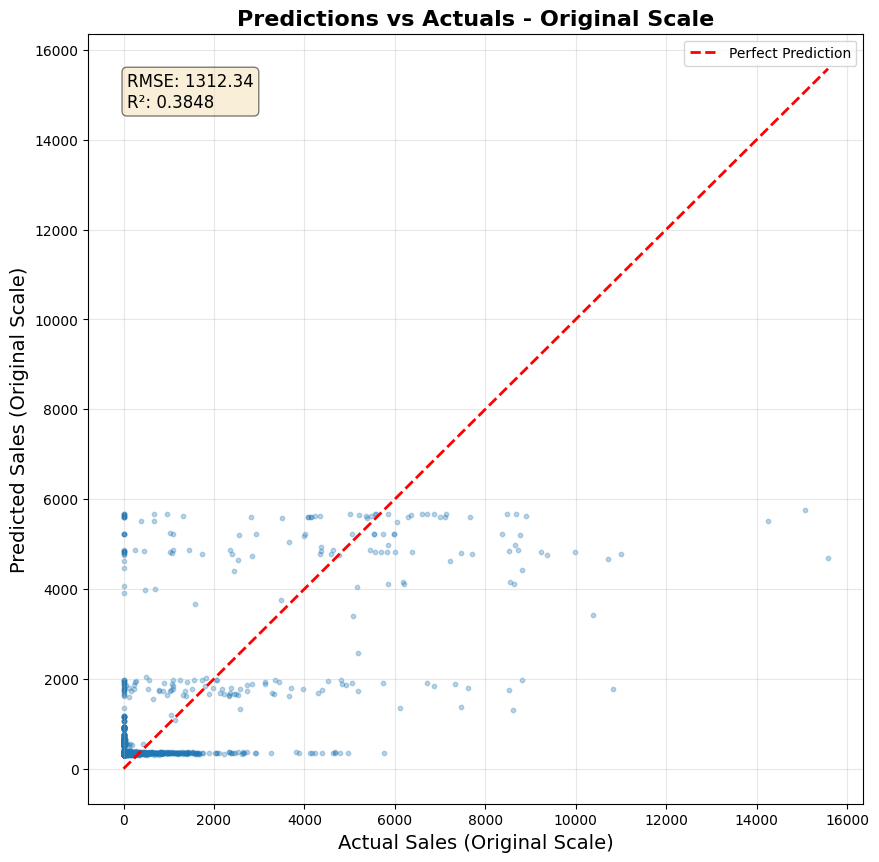


ANALYSIS COMPLETE!


In [16]:
# ============================================================================
# MAKE PREDICTIONS ON TEST SET (ADD THIS SECTION!)
# ============================================================================

print("\n" + "="*70)
print("MAKING PREDICTIONS ON TEST SET")
print("="*70)

# Load best model
model.load_state_dict(torch.load('best_hybrid_model.pt', map_location=device))
model.eval()

predictions = []
actuals = []

print(f"Making predictions on {len(test_snapshots)} test snapshots...")

with torch.no_grad():
    for snap in test_snapshots:
        x = torch.tensor(snap.x, dtype=torch.float).to(device)
        edge_index = torch.tensor(snap.edge_index, dtype=torch.long).to(device)
        edge_attr = torch.tensor(snap.edge_attr, dtype=torch.float).to(device) if snap.edge_attr is not None else None
        y = torch.tensor(snap.y, dtype=torch.float).to(device)
        
        # Predict
        pred = model(x, edge_index, edge_attr)
        
        # Store (keep on CPU as numpy)
        predictions.append(pred.cpu().numpy())
        actuals.append(y.cpu().numpy())

print(f"✓ Predictions complete! Collected {len(predictions)} snapshots")

# Calculate scaled metrics (for comparison)
preds_flat_scaled = np.concatenate(predictions)
actuals_flat_scaled = np.concatenate(actuals)

mae = mean_absolute_error(actuals_flat_scaled, preds_flat_scaled)
rmse = np.sqrt(mean_squared_error(actuals_flat_scaled, preds_flat_scaled))
r2 = r2_score(actuals_flat_scaled, preds_flat_scaled)

print("\n" + "="*70)
print("TEST RESULTS (SCALED)")
print("="*70)
print(f"MAE:   {mae:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"R²:    {r2:.4f}")
print("="*70)

# ============================================================================
# NOW INVERSE TRANSFORM TO ORIGINAL SCALE
# ============================================================================

import pickle

print("\n" + "="*70)
print("CONVERTING PREDICTIONS TO ORIGINAL SCALE")
print("="*70)

# Load the saved scaler
scaler_path = r'C:\Users\KIIT0001\ai_engine\trade_data\target_scaler.pkl'
with open(scaler_path, 'rb') as f:
    target_scaler = pickle.load(f)

print(f"✓ Loaded target scaler")
print(f"  Mean: {target_scaler.mean_[0]:.2f}")
print(f"  Std:  {target_scaler.scale_[0]:.2f}")

print(f"\nScaled values:")
print(f"  Predictions: min={preds_flat_scaled.min():.2f}, max={preds_flat_scaled.max():.2f}, mean={preds_flat_scaled.mean():.2f}")
print(f"  Actuals: min={actuals_flat_scaled.min():.2f}, max={actuals_flat_scaled.max():.2f}, mean={actuals_flat_scaled.mean():.2f}")

# Inverse transform to original scale
preds_flat_original = target_scaler.inverse_transform(preds_flat_scaled.reshape(-1, 1)).flatten()
actuals_flat_original = target_scaler.inverse_transform(actuals_flat_scaled.reshape(-1, 1)).flatten()

print(f"\nOriginal scale values:")
print(f"  Predictions: min={preds_flat_original.min():.2f}, max={preds_flat_original.max():.2f}, mean={preds_flat_original.mean():.2f}")
print(f"  Actuals: min={actuals_flat_original.min():.2f}, max={actuals_flat_original.max():.2f}, mean={actuals_flat_original.mean():.2f}")

# Calculate metrics in ORIGINAL scale
mae_original = mean_absolute_error(actuals_flat_original, preds_flat_original)
rmse_original = np.sqrt(mean_squared_error(actuals_flat_original, preds_flat_original))
r2_original = r2_score(actuals_flat_original, preds_flat_original)

# MAPE (only where actuals > 0)
mask = actuals_flat_original > 0
if mask.sum() > 0:
    mape_original = np.mean(np.abs((actuals_flat_original[mask] - preds_flat_original[mask]) / actuals_flat_original[mask])) * 100
else:
    mape_original = float('nan')

print("\n" + "="*70)
print("TEST RESULTS (ORIGINAL SCALE) ⭐")
print("="*70)
print(f"MAE:   {mae_original:.2f}")
print(f"RMSE:  {rmse_original:.2f}")
print(f"R²:    {r2_original:.4f}")
print(f"MAPE:  {mape_original:.2f}%")
print("="*70)

# Compare with scaled results
print("\nComparison (Scaled vs Original):")
print(f"{'Metric':<10} {'Scaled':<15} {'Original':<15}")
print(f"{'MAE':<10} {mae:.4f}{'':<10} {mae_original:.2f}")
print(f"{'RMSE':<10} {rmse:.4f}{'':<10} {rmse_original:.2f}")
print(f"{'R²':<10} {r2:.4f}{'':<10} {r2_original:.4f}")

# ============================================================================
# COMPARE WITH BENCHMARK PAPER
# ============================================================================

print("\n" + "="*70)
print("COMPARISON WITH BENCHMARK PAPER (Production Forecasting)")
print("="*70)

benchmark = {
    'ARMA': 37.45,
    'GRU': 32.35,
    'LSTM': 30.21,
    'DCRNN': 27.94,
    'TGCN': 27.92,
    'GConvGRU': 28.04
}

print(f"{'Model':<20} {'RMSE':<15} {'vs Your Model':<20}")
print("-" * 55)

for model_name, paper_rmse in benchmark.items():
    diff = rmse_original - paper_rmse
    if diff < 0:
        comparison = f"✓ You're BETTER by {abs(diff):.2f}"
    else:
        comparison = f"✗ Paper is better by {diff:.2f}"
    print(f"{model_name:<20} {paper_rmse:<15.2f} {comparison}")

print("-" * 55)
print(f"{'Your Hybrid Model':<20} {rmse_original:<15.2f}")
print("="*70)

# Calculate improvement percentage
best_paper_rmse = min(benchmark.values())  # 27.92 (TGCN)
if rmse_original < best_paper_rmse:
    improvement = (best_paper_rmse - rmse_original) / best_paper_rmse * 100
    print(f"\n🎉 CONGRATULATIONS! You beat the paper's best model (TGCN) by {improvement:.1f}%!")
else:
    gap = (rmse_original - best_paper_rmse) / best_paper_rmse * 100
    print(f"\n⚠️ Your model is {gap:.1f}% behind the paper's best (TGCN: {best_paper_rmse:.2f})")

# Save results
results_df = pd.DataFrame({
    'actual_scaled': actuals_flat_scaled,
    'predicted_scaled': preds_flat_scaled,
    'actual_original': actuals_flat_original,
    'predicted_original': preds_flat_original,
    'error_original': preds_flat_original - actuals_flat_original
})

results_df.to_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\predictions_comparison.csv', index=False)
print(f"\n✓ Saved detailed comparison to predictions_comparison.csv")

# ============================================================================
# VISUALIZE RESULTS
# ============================================================================

import matplotlib.pyplot as plt

# Plot 1: Predictions vs Actuals (Original Scale)
plt.figure(figsize=(10, 10))
plt.scatter(actuals_flat_original, preds_flat_original, alpha=0.3, s=10)
min_val = min(actuals_flat_original.min(), preds_flat_original.min())
max_val = max(actuals_flat_original.max(), preds_flat_original.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Sales (Original Scale)', fontsize=14)
plt.ylabel('Predicted Sales (Original Scale)', fontsize=14)
plt.title('Predictions vs Actuals - Original Scale', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.text(0.05, 0.95, f'RMSE: {rmse_original:.2f}\nR²: {r2_original:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.savefig(r'C:\Users\KIIT0001\ai_engine\trade_data\predictions_vs_actuals_original.png', 
            dpi=300, bbox_inches='tight')
print("\n✓ Saved: predictions_vs_actuals_original.png")
plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)



In [17]:
# ============================================================================
# INVERSE TRANSFORM TO ORIGINAL SCALE
# ============================================================================

import pickle
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n" + "="*70)
print("CONVERTING PREDICTIONS TO ORIGINAL SCALE")
print("="*70)

# Load the saved scaler
scaler_path = r'C:\Users\KIIT0001\ai_engine\trade_data\target_scaler.pkl'
with open(scaler_path, 'rb') as f:
    target_scaler = pickle.load(f)

print(f"✓ Loaded target scaler")
print(f"  Mean: {target_scaler.mean_[0]:.2f}")
print(f"  Std:  {target_scaler.scale_[0]:.2f}")

# Flatten predictions and actuals
preds_flat_scaled = np.concatenate(predictions)    # Scaled predictions
actuals_flat_scaled = np.concatenate(actuals)      # Scaled actuals

print(f"\nScaled values:")
print(f"  Predictions: min={preds_flat_scaled.min():.2f}, max={preds_flat_scaled.max():.2f}, mean={preds_flat_scaled.mean():.2f}")
print(f"  Actuals: min={actuals_flat_scaled.min():.2f}, max={actuals_flat_scaled.max():.2f}, mean={actuals_flat_scaled.mean():.2f}")

# Inverse transform to original scale
preds_flat_original = target_scaler.inverse_transform(preds_flat_scaled.reshape(-1, 1)).flatten()
actuals_flat_original = target_scaler.inverse_transform(actuals_flat_scaled.reshape(-1, 1)).flatten()

print(f"\nOriginal scale values:")
print(f"  Predictions: min={preds_flat_original.min():.2f}, max={preds_flat_original.max():.2f}, mean={preds_flat_original.mean():.2f}")
print(f"  Actuals: min={actuals_flat_original.min():.2f}, max={actuals_flat_original.max():.2f}, mean={actuals_flat_original.mean():.2f}")

# Calculate metrics in ORIGINAL scale
mae_original = mean_absolute_error(actuals_flat_original, preds_flat_original)
rmse_original = np.sqrt(mean_squared_error(actuals_flat_original, preds_flat_original))
r2_original = r2_score(actuals_flat_original, preds_flat_original)

# MAPE (only where actuals > 0)
mask = actuals_flat_original > 0
mape_original = np.mean(np.abs((actuals_flat_original[mask] - preds_flat_original[mask]) / actuals_flat_original[mask])) * 100

print("\n" + "="*70)
print("TEST RESULTS (ORIGINAL SCALE) ⭐")
print("="*70)
print(f"MAE:   {mae_original:.2f}")
print(f"RMSE:  {rmse_original:.2f}")
print(f"R²:    {r2_original:.4f}")
print(f"MAPE:  {mape_original:.2f}%")
print("="*70)

# Compare with scaled results
print("\nComparison (Scaled vs Original):")
print(f"{'Metric':<10} {'Scaled':<15} {'Original':<15}")
print(f"{'MAE':<10} {mae:.4f}{'':<10} {mae_original:.2f}")
print(f"{'RMSE':<10} {rmse:.4f}{'':<10} {rmse_original:.2f}")
print(f"{'R²':<10} {r2:.4f}{'':<10} {r2_original:.4f}")

# Save original scale predictions for further analysis
results_df = pd.DataFrame({
    'actual_scaled': actuals_flat_scaled,
    'predicted_scaled': preds_flat_scaled,
    'actual_original': actuals_flat_original,
    'predicted_original': preds_flat_original,
    'error_original': preds_flat_original - actuals_flat_original
})

results_df.to_csv(r'C:\Users\KIIT0001\ai_engine\trade_data\predictions_comparison.csv', index=False)
print(f"\n✓ Saved detailed comparison to predictions_comparison.csv")


CONVERTING PREDICTIONS TO ORIGINAL SCALE
✓ Loaded target scaler
  Mean: 912.85
  Std:  2590.29

Scaled values:
  Predictions: min=-0.23, max=1.87, mean=-0.02
  Actuals: min=-0.35, max=5.66, mean=-0.11

Original scale values:
  Predictions: min=306.67, max=5755.26, mean=850.30
  Actuals: min=-0.00, max=15579.33, mean=640.54

TEST RESULTS (ORIGINAL SCALE) ⭐
MAE:   737.83
RMSE:  1312.34
R²:    0.3848
MAPE:  1006.50%

Comparison (Scaled vs Original):
Metric     Scaled          Original       
MAE        0.2848           737.83
RMSE       0.5066           1312.34
R²         0.3848           0.3848

✓ Saved detailed comparison to predictions_comparison.csv
